# Analisis Preprocessing & Informasi Dataset SEN12MS-CR-TS

Notebook ini dibuat khusus untuk mendokumentasikan langkah **preprocessing data** citra satelit dan memvisualisasikan rincian **64 Kanal Input** berdimensi `[64, 256, 256]` yang digunakan oleh model Baseline v14 dan GAN v9 untuk Tugas Akhir.

**Alur Preprocessing & Desain Sistem Input**:
1. **Sentinel-2 (Spektral/Optik)**: Memiliki 13 band (saluran spektral) untuk setiap tanggal. Dengan 4 tanggal perekaman, total saluran optik adalah $13 \times 4 = 52$ kanal.
2. **Sentinel-1 (Radar/SAR)**: Memiliki 2 band (VV dan VH) untuk setiap tanggal. Dengan 4 tanggal perekaman, total saluran radar adalah $2 \times 4 = 8$ kanal. Sensor ini menembus awan dan merekam kekasaran permukaan tanah.
3. **Peta Probabilitas Awan (Cloud Probability)**: Peta awan temporal per tanggal (1 saluran per tanggal). Dengan 4 tanggal, total adalah $1 \times 4 = 4$ kanal.
4. **Total input**: $52 + 8 + 4 = 64$ kanal input. Hal ini digabungkan (concatenated) menjadi matriks 3D berukuran `[64, 256, 256]` sebagai input model deep learning.

## 1. Import Library & Konfigurasi Path Lokal

**Penjelasan Alur**:
Sel di bawah mengimpor pustaka utama untuk pengolahan data penginderaan jauh:
- `tifffile`: Library khusus untuk membaca file berformat TIFF (`.tif`) 16-bit satelit tanpa kehilangan akurasi floating point.
- `numpy`: Mengelola operasi aljabar linier dan array 3D/4D untuk piksel citra.
- `pandas` & `matplotlib/seaborn`: Menyusun statistik deskriptif dan menggambarkan visualisasi grafik.
- `torch` (PyTorch): Sebagai framework backend untuk memproses data menggunakan tensor.

In [1]:
import os
import re
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import tifffile

# Definisikan path ke dataset lokal Anda
DATASET_PATH = Path(r"c:/Users/Vulpolish/Downloads/Tugas Akhir/asiaWest_n")
print("Dataset Path:", DATASET_PATH.exists())

Dataset Path: True


## 2. Pindai Struktur Dataset & Buat Tabel Ringkasan Sampel

**Penjelasan Alur & Validasi Sampel**:
Satelit Sentinel-1 dan Sentinel-2 menyimpan data dalam format penamaan file yang kompleks (mengandung ID ROI, ID Patch, tipe sensor, tanggal perekaman). 
Fungsi `scan_dataset` di bawah memindai direktori lokal `asiaWest_n` di laptop Anda, mengelompokkan file berdasarkan kesamaan lokasi (*patch*) dan memastikan setiap sampel memiliki data deret waktu lengkap (4 tanggal perekaman Sentinel-1 dan 4 tanggal Sentinel-2) tanpa ada data yang korup atau hilang. Hasil pemindaian disimpan dalam bentuk DataFrame indeks untuk proses loading data selanjutnya.

In [2]:
SEN12_RE = re.compile(
    r"^(?P<sensor>s[12])_(?P<roi_group>ROIs\d+)_(?P<roi_id>\d+)_ImgNo_"
    r"(?P<time_id>\d+)_(?P<date>\d{4}-\d{2}-\d{2})_patch_(?P<patch_id>\d+)\.tif$",
    re.IGNORECASE,
)

def scan_dataset(root: Path):
    grouped = {}
    if not root.exists():
        print("Dataset folder tidak ditemukan secara lokal. Silakan hubungkan dataset atau jalankan di Kaggle.")
        return pd.DataFrame()
        
    for path in sorted(root.rglob("*.tif")):
        m = SEN12_RE.match(path.name)
        if not m: continue
        gd = m.groupdict()
        key = (gd["roi_group"], gd["roi_id"], int(gd["patch_id"]))
        sensor = gd["sensor"].upper()
        time_id = int(gd["time_id"])
        item = grouped.setdefault(key, {"S1_paths": {}, "S2_paths": {}, "dates": {}})
        item[sensor + "_paths"][time_id] = path
        item["dates"][(sensor, time_id)] = gd["date"]

    rows = []
    for (roi_group, roi_id, patch_id), item in grouped.items():
        if len(item["S1_paths"]) == 4 and len(item["S2_paths"]) == 4:
            rows.append({
                "ROI Group": roi_group,
                "ROI ID": roi_id,
                "Patch ID": patch_id,
                "S2 Dates": ", ".join(item["dates"][("S2", t)] for t in range(4)),
                "S1 Dates": ", ".join(item["dates"][("S1", t)] for t in range(4)),
                "S2_paths": item["S2_paths"],
                "S1_paths": item["S1_paths"]
            })
    return pd.DataFrame(rows)

samples_df = scan_dataset(DATASET_PATH)
if not samples_df.empty:
    print(f"Total Sampel Multi-Temporal Lengkap: {len(samples_df)}")
    display(samples_df.drop(columns=["S2_paths", "S1_paths"]).head())
else:
    print("Belum ada sampel terdeteksi di path lokal.")

Total Sampel Multi-Temporal Lengkap: 1920


,ROI Group,ROI ID,Patch ID,S2 Dates,S1 Dates
0,ROIs1868,127,0,"2018-01-08, 2018-01-23, 2018-02-02, 2018-02-12","2018-01-07, 2018-01-19, 2018-01-31, 2018-02-12"
1,ROIs1868,127,1,"2018-01-08, 2018-01-23, 2018-02-02, 2018-02-12","2018-01-07, 2018-01-19, 2018-01-31, 2018-02-12"
2,ROIs1868,127,10,"2018-01-08, 2018-01-23, 2018-02-02, 2018-02-12","2018-01-07, 2018-01-19, 2018-01-31, 2018-02-12"
3,ROIs1868,127,100,"2018-01-08, 2018-01-23, 2018-02-02, 2018-02-12","2018-01-07, 2018-01-19, 2018-01-31, 2018-02-12"
4,ROIs1868,127,101,"2018-01-08, 2018-01-23, 2018-02-02, 2018-02-12","2018-01-07, 2018-01-19, 2018-01-31, 2018-02-12"


## 3. Sintaks Fungsi Preprocessing

**Penjelasan Formula Preprocessing**:

1. **Fungsi `read_tif`**:
   Membaca format citra TIFF satelit beresolusi tinggi ke dalam NumPy array, lalu menyusun posisinya agar berformat `[Kanal, Tinggi, Lebar]` (dimensi standard PyTorch).

2. **Fungsi `normalize_s2` (Sentinel-2 Optik)**:
   * **Reflectance DN Scaling**: Nilai piksel mentah dari Sentinel-2 L2A direpresentasikan dalam format Digital Number (DN) berskala $0 - 10000$.
   * **Normalisasi**: Kita membaginya dengan konstanta `10000.0` agar nilainya merapat ke rentang spektral standard $[0, 1]$. Piksel awan tebal memiliki nilai pantulan yang sangat tinggi dan dapat mendekati atau sedikit melebihi $1,0$ sebelum dilakukan `np.clip`.

3. **Fungsi `normalize_s1` (Sentinel-1 Radar SAR)**:
   * **dB Standardization**: Nilai piksel radar berupa koefisien hamburan balik (backscatter coefficient) dalam skala desibel (dB) yang umumnya berkisar dari $-35\text{ dB}$ (permukaan air/tanah halus) hingga $+5\text{ dB}$ (struktur perkotaan/hutan lebat).
   * **Normalisasi**: Dikonversi menjadi skala linier $[0, 1]$ menggunakan rumus pergeseran linier:
     $$\text{S1}_{\text{norm}} = \frac{\text{S1} + 35,0}{40,0}$$
     Nilai piksel yang berada di luar batas akan dipotong (*clipped*) menggunakan `np.clip` agar tetap berada dalam batas $[0, 1]$.

In [3]:
def read_tif(path: Path) -> np.ndarray:
    arr = tifffile.imread(path)
    if arr.ndim == 2: 
        arr = arr[np.newaxis, :, :]
    if arr.ndim == 3 and arr.shape[-1] in {2, 3, 4, 13}:
        arr = np.moveaxis(arr, -1, 0)
    return arr.astype(np.float32)

def normalize_s2(arr: np.ndarray) -> np.ndarray:
    # Skala reflectance 0-10000 ke [0, 1]
    return np.clip(arr / 10000.0, 0, 1).astype(np.float32)

def normalize_s1(arr: np.ndarray) -> np.ndarray:
    # Skala VV/VH dB ke [0, 1]
    return np.clip((arr + 35.0) / 40.0, 0, 1).astype(np.float32)

def robust_scale(arr: np.ndarray, p_low: float = 2.0, p_high: float = 98.0) -> np.ndarray:
    lo, hi = np.nanpercentile(arr, [p_low, p_high])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return np.zeros_like(arr, dtype=np.float32)
    return np.clip((arr - lo) / (hi - lo), 0, 1).astype(np.float32)

def spectral_cloud_probability_s2(s2_norm: np.ndarray) -> np.ndarray:
    blue, green, red = s2_norm[1], s2_norm[2], s2_norm[3]
    nir = s2_norm[7] if s2_norm.shape[0] > 7 else red
    cirrus = s2_norm[10] if s2_norm.shape[0] > 10 else blue
    swir1 = s2_norm[11] if s2_norm.shape[0] > 11 else nir
    swir2 = s2_norm[12] if s2_norm.shape[0] > 12 else swir1
    brightness = (red + green + blue) / 3.0
    whiteness = 1.0 - np.std([red, green, blue], axis=0)
    ndvi = (nir - red) / (nir + red + 1e-6)
    ndsi = (green - swir1) / (green + swir1 + 1e-6)
    visible_cloud = brightness * np.clip(whiteness, 0, 1)
    high_band = 0.60 * cirrus + 0.25 * swir1 + 0.15 * swir2
    prob = 0.62 * visible_cloud + 0.38 * high_band
    veg_penalty = np.clip((ndvi - 0.20) / 0.35, 0, 1)
    snow_penalty = np.clip((ndsi - 0.35) / 0.35, 0, 1) * np.clip((brightness - 0.20) / 0.45, 0, 1)
    return np.clip(prob * (1.0 - 0.35 * veg_penalty) * (1.0 - 0.25 * snow_penalty), 0, 1).astype(np.float32)

def temporal_cloud_probabilities_s2(stack_norm: np.ndarray) -> np.ndarray:
    spectral = np.stack([spectral_cloud_probability_s2(stack_norm[t]) for t in range(stack_norm.shape[0])], axis=0)
    brightness = (stack_norm[:, 3] + stack_norm[:, 2] + stack_norm[:, 1]) / 3.0
    temporal_floor = np.percentile(brightness, 20, axis=0)
    temporal_median = np.median(brightness, axis=0)
    brighter_than_clear = np.clip((brightness - temporal_floor) / 0.18, 0, 1)
    brighter_than_median = np.clip((brightness - temporal_median) / 0.12, 0, 1)
    probs = 0.58 * spectral + 0.42 * (0.65 * brighter_than_clear + 0.35 * brighter_than_median)
    return np.clip(probs, 0, 1).astype(np.float32)

def soft_cloud_mask_from_prob(prob: np.ndarray) -> np.ndarray:
    return np.clip((prob - 0.08) / (0.20 - 0.08), 0, 1).astype(np.float32)

def clear_pixel_composite_from_stack(stack: np.ndarray, probs: np.ndarray):
    best_map = np.argmin(probs, axis=0).astype(np.int64)
    weights = np.exp(-10.0 * probs).astype(np.float32) + 1e-5
    weights = weights / weights.sum(axis=0, keepdims=True)
    target_weighted = (stack * weights[:, None]).sum(axis=0).astype(np.float32)
    target_best = np.zeros_like(target_weighted)
    for t in range(stack.shape[0]):
        pick = best_map == t
        target_best[:, pick] = stack[t, :, pick].T
    target = (0.45 * target_best + 0.55 * target_weighted).astype(np.float32)
    cloud_t0 = soft_cloud_mask_from_prob(probs[0])
    return target, cloud_t0


## 4. Analisis Statistik Deskriptif Nilai Piksel

**Penjelasan Analisis Statistika**:
Tabel di bawah menyajikan karakteristik nilai piksel numerik pada citra satelit sebelum dan sesudah dinormalisasi. Statistik deskriptif seperti **Mean (Rata-rata)** dan **Std (Simpangan Baku)** memberikan gambaran pemusatan dan penyebaran data piksel satelit. 
Analisis ini menggunakan sampel acak sebanyak 20 patch citra satelit (total piksel spektral optik Sentinel-2 yang dianalisis adalah $20 \text{ patch} \times 4 \text{ tanggal} \times 3 \text{ band} \times 256 \times 256 \text{ piksel} = 15.728.640 \text{ piksel}$, dan piksel radar Sentinel-1 sebanyak $10.485.760 \text{ piksel}$). Jumlah data yang sangat besar ini menjamin representasi statistik yang stabil (Hukum Bilangan Besar/Law of Large Numbers).

In [4]:
if not samples_df.empty:
    # Ambil sampel subset 20 patch secara acak untuk analisis statistik cepat
    np.random.seed(42)
    subset_indices = np.random.choice(len(samples_df), min(20, len(samples_df)), replace=False)
    
    s2_pixels = []
    s1_pixels = []
    
    for idx in subset_indices:
        row = samples_df.iloc[idx]
        # Load Sentinel-2 t0 (B2, B3, B4 - RGB)
        s2_img = read_tif(row["S2_paths"][0])
        s2_pixels.append(s2_img[[1, 2, 3]].flatten()) # B2, B3, B4
        
        # Load Sentinel-1 t0 (VV, VH)
        s1_img = read_tif(row["S1_paths"][0])
        s1_pixels.append(s1_img.flatten())
        
    s2_pixels = np.concatenate(s2_pixels)
    s1_pixels = np.concatenate(s1_pixels)
    
    print("=== STATISTIK CITRA SATELLITE MENTAH (RAW VALS) ===")
    stats_raw = pd.DataFrame({
        "Sentinel-2 (B2-B4 Spektral)": pd.Series(s2_pixels).describe(percentiles=[.05, .25, .50, .75, .95]),
        "Sentinel-1 (Radar SAR VV/VH)": pd.Series(s1_pixels).describe(percentiles=[.05, .25, .50, .75, .95])
    })
    display(stats_raw.round(4))
    
    # Analisis Piksel setelah Normalisasi
    print("\n=== STATISTIK CITRA SETELAH NORMALISASI [0,1] ===")
    stats_norm = pd.DataFrame({
        "Sentinel-2 (Normalized S2)": pd.Series(normalize_s2(s2_pixels)).describe(percentiles=[.05, .25, .50, .75, .95]),
        "Sentinel-1 (Normalized S1)": pd.Series(normalize_s1(s1_pixels)).describe(percentiles=[.05, .25, .50, .75, .95])
    })
    display(stats_norm.round(4))
else:
    print("Belum ada data untuk dihitung statistiknya.")

=== STATISTIK CITRA SATELLITE MENTAH (RAW VALS) ===


,Sentinel-2 (B2-B4 Spektral),Sentinel-1 (Radar SAR VV/VH)
count,3.932160e+06,2.621440e+06
mean,1.757504e+03,-1.588220e+01
std,1.153361e+03,6.644200e+00
min,2.800000e+02,-4.822410e+01
5%,6.460000e+02,-2.657360e+01
25%,1.030000e+03,-2.080670e+01
50%,1.434000e+03,-1.556570e+01
75%,1.943000e+03,-1.098990e+01
95%,4.556000e+03,-5.655000e+00
max,1.062900e+04,2.188240e+01



=== STATISTIK CITRA SETELAH NORMALISASI [0,1] ===


,Sentinel-2 (Normalized S2),Sentinel-1 (Normalized S1)
count,3.932160e+06,2.621440e+06
mean,1.758000e-01,4.782000e-01
std,1.153000e-01,1.650000e-01
min,2.800000e-02,0.000000e+00
5%,6.460000e-02,2.107000e-01
25%,1.030000e-01,3.548000e-01
50%,1.434000e-01,4.859000e-01
75%,1.943000e-01,6.003000e-01
95%,4.556000e-01,7.336000e-01
max,1.000000e+00,1.000000e+00


### Visualisasi Distribusi (Histogram & Density Plot)

**Penjelasan Visualisasi**:
Density plot di bawah memvisualisasikan bentuk sebaran frekuensi piksel:
*   Kurva **Sentinel-2** menunjukkan puncak konsentrasi di nilai rendah ($0,05 - 0,20$) yang mewakili piksel daratan normal (lahan, vegetasi, air), dan memiliki ekor landai ke kanan mendekati nilai $1,0$ yang merupakan representasi piksel awan putih tebal yang sangat cerah (positively skewed).
*   Kurva **Sentinel-1 (Radar)** berdistribusi lebih simetris di sekitar nilai tengah $0,4 - 0,6$ karena data radar SAR mengukur kekasaran permukaan tanah yang relatif konstan dan stabil tanpa terganggu oleh keberadaan awan di atmosfer.

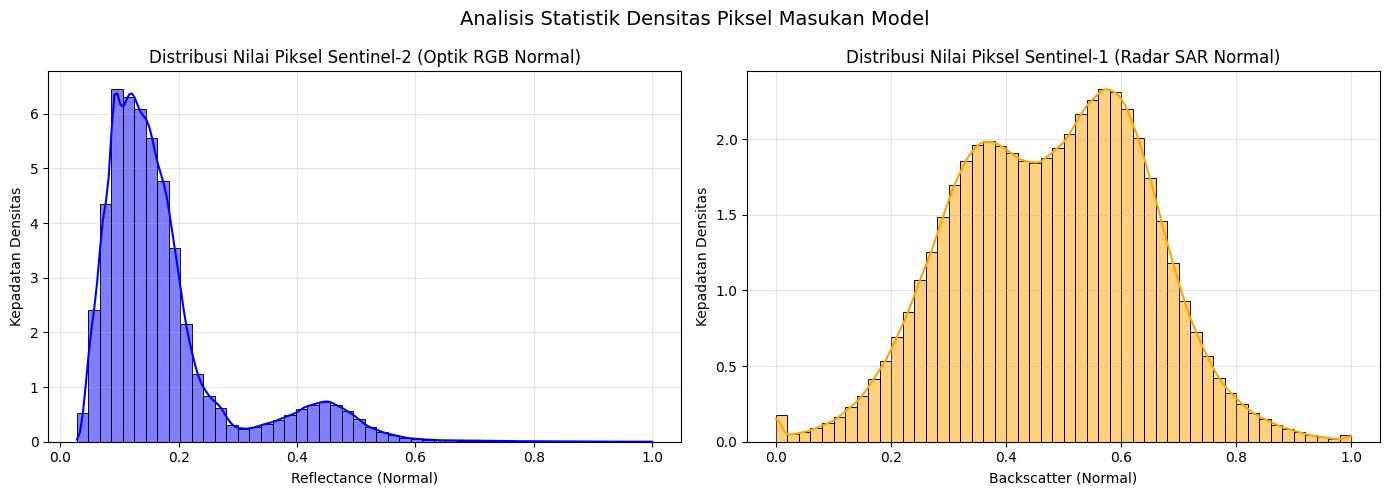

Visualisasi berhasil disimpan sebagai 'distribusi_piksel_s1_s2.png'.


In [5]:
if not samples_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram Sentinel-2
    sns.histplot(normalize_s2(s2_pixels), bins=50, kde=True, ax=axes[0], color='blue', stat='density')
    axes[0].set_title("Distribusi Nilai Piksel Sentinel-2 (Optik RGB Normal)")
    axes[0].set_xlabel("Reflectance (Normal)")
    axes[0].set_ylabel("Kepadatan Densitas")
    axes[0].grid(True, alpha=0.3)
    
    # Histogram Sentinel-1
    sns.histplot(normalize_s1(s1_pixels), bins=50, kde=True, ax=axes[1], color='orange', stat='density')
    axes[1].set_title("Distribusi Nilai Piksel Sentinel-1 (Radar SAR Normal)")
    axes[1].set_xlabel("Backscatter (Normal)")
    axes[1].set_ylabel("Kepadatan Densitas")
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle("Analisis Statistik Densitas Piksel Masukan Model", fontsize=14)
    plt.tight_layout()
    plt.savefig(DATASET_PATH.parent / "distribusi_piksel_s1_s2.png", dpi=180)
    plt.show()
    print("Visualisasi berhasil disimpan sebagai 'distribusi_piksel_s1_s2.png'.")

### Visualisasi Sampel Pra-pengolahan Spasial (Peta Awan, Radar, & Target Bersih)

**Penjelasan Visualisasi**:
Di bawah ini adalah representasi visual dari hasil pra-pengolahan citra satelit pada wilayah lokal Anda untuk satu sampel patch:
1. **Sentinel-2 RGB**: Citra optik asli Sentinel-2 di waktu $t_0$ yang tertutup awan putih tebal.
2. **Sentinel-1 Radar SAR**: Visualisasi radar Sentinel-1 dalam format False Color (Red = VV, Green = VH, Blue = |VV - VH|). Tampak bahwa radar mampu menembus awan dan merekam garis permukaan tanah yang tersembunyi.
3. **Cloud Probability Map**: Nilai probabilitas keberadaan awan spektral dan temporal (piksel lebih putih menunjukkan probabilitas awan lebih tinggi).
4. **Soft Cloud Mask**: Masker awan halus yang terbentuk setelah pemotongan threshold ($0,08 - 0,20$). Masker ini menentukan piksel mana yang akan diperbaiki oleh model.
5. **Pseudo Ground Truth (Clear Target)**: Hasil komposit piksel temporal bersih terbaik yang akan dijadikan target latih model.

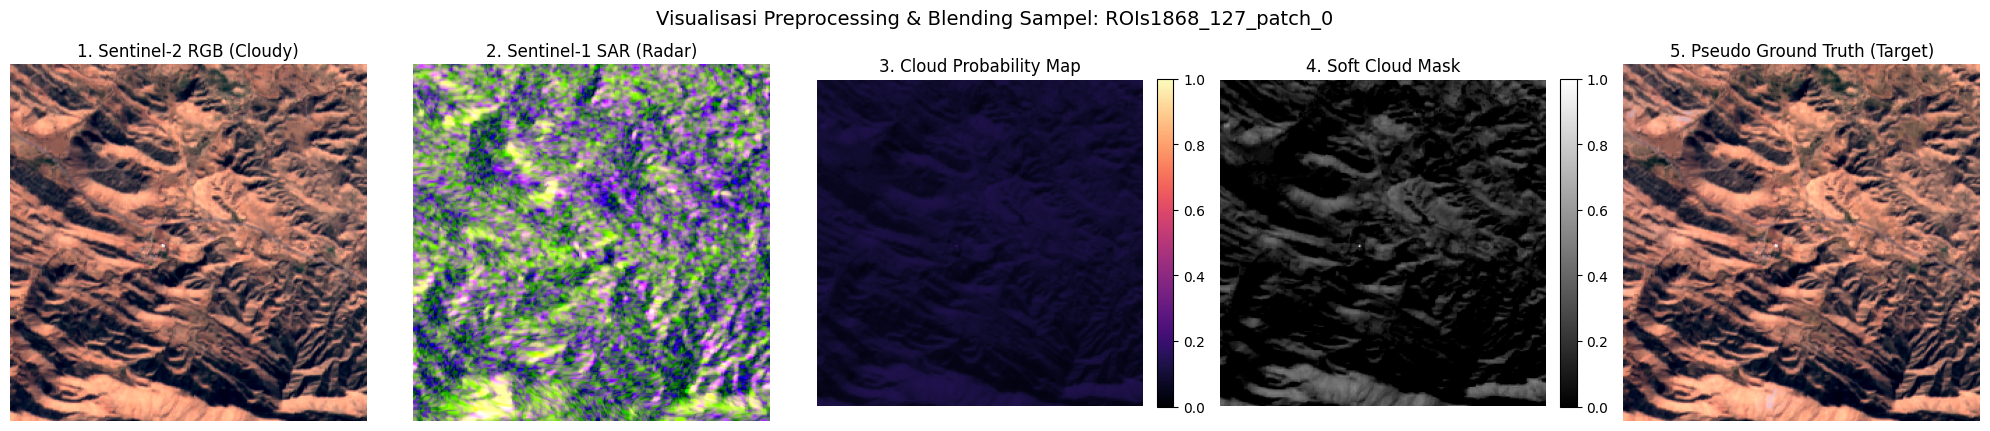

Visualisasi alur preprocessing berhasil disimpan sebagai 'visualisasi_alur_preprocessing.png'.


In [6]:
if not samples_df.empty:
    # Ambil sampel pertama untuk visualisasi alur
    row = samples_df.iloc[0]
    s2_list = [normalize_s2(read_tif(row["S2_paths"][t])) for t in range(4)]
    s1_list = [normalize_s1(read_tif(row["S1_paths"][t])) for t in range(4)]
    
    # Hitung probabilitas awan & masker t0
    probs = temporal_cloud_probabilities_s2(np.stack(s2_list, axis=0))
    cloud_prob_t0 = probs[0]
    mask_t0 = soft_cloud_mask_from_prob(cloud_prob_t0)
    
    # Hitung target komposit temporal
    target, _ = clear_pixel_composite_from_stack(np.stack(s2_list, axis=0), probs)
    
    # Buat RGB visual menggunakan robust scaling
    s2_rgb = np.stack([s2_list[0][3], s2_list[0][2], s2_list[0][1]], axis=-1)
    s2_rgb = robust_scale(s2_rgb)
    
    target_rgb = np.stack([target[3], target[2], target[1]], axis=-1)
    target_rgb = robust_scale(target_rgb)
    
    vv = robust_scale(s1_list[0][0])
    vh = robust_scale(s1_list[0][1])
    diff = robust_scale(np.abs(s1_list[0][0] - s1_list[0][1]))
    s1_rgb = np.stack([vv, vh, diff], axis=-1)
    
    # Plot visualisasi
    fig, axes = plt.subplots(1, 5, figsize=(20, 4.5))
    
    axes[0].imshow(s2_rgb)
    axes[0].set_title("1. Sentinel-2 RGB (Cloudy)")
    axes[0].axis("off")
    
    axes[1].imshow(s1_rgb)
    axes[1].set_title("2. Sentinel-1 SAR (Radar)")
    axes[1].axis("off")
    
    im_prob = axes[2].imshow(cloud_prob_t0, cmap="magma", vmin=0, vmax=1)
    axes[2].set_title("3. Cloud Probability Map")
    axes[2].axis("off")
    plt.colorbar(im_prob, ax=axes[2], fraction=0.046, pad=0.04)
    
    im_mask = axes[3].imshow(mask_t0, cmap='gray', vmin=0, vmax=1)
    axes[3].set_title('4. Soft Cloud Mask')
    axes[3].axis('off')
    plt.colorbar(im_mask, ax=axes[3], fraction=0.046, pad=0.04)
    
    axes[4].imshow(target_rgb)
    axes[4].set_title("5. Pseudo Ground Truth (Target)")
    axes[4].axis("off")
    
    plt.suptitle(f"Visualisasi Preprocessing & Blending Sampel: {row['ROI Group']}_{row['ROI ID']}_patch_{row['Patch ID']}", fontsize=14, y=0.98)
    plt.tight_layout()
    plt.savefig(DATASET_PATH.parent / "visualisasi_alur_preprocessing.png", dpi=180)
    plt.show()
    print("Visualisasi alur preprocessing berhasil disimpan sebagai 'visualisasi_alur_preprocessing.png'.")


## 5. Struktur Lengkap 64 Kanal Input (Untuk Dokumen Word/Tesis)

Tabel di bawah mendefinisikan letak indeks kanal spektral, radar, dan probabilitas awan pada input dimensi `[64, 256, 256]`. Tabel ini sangat penting untuk disertakan pada Bab III (Metodologi) atau Bab IV (Analisis Data) Tugas Akhir Anda untuk memperjelas susunan kanal masukan model multi-temporal.

In [7]:
channels_info = []

# Sentinel-2 Bands
s2_bands = ["B1 (Coasta)", "B2 (Blue)", "B3 (Green)", "B4 (Red)", "B5 (RE-1)", 
            "B6 (RE-2)", "B7 (RE-3)", "B8 (NIR-1)", "B8A (NIR-2)", "B9 (Water)", 
            "B10 (Cirrus)", "B11 (SWIR-1)", "B12 (SWIR-2)"]

idx = 0
for t in range(4):
    for band in s2_bands:
        channels_info.append({
            "Indeks Kanal": idx,
            "Sumber Data": f"Sentinel-2 (Optik)",
            "Waktu": f"t{t}",
            "Keterangan Band": band,
            "Normalisasi": "Bagi 10000"
        })
        idx += 1

# Cloud Probabilities
for t in range(4):
    channels_info.append({
        "Indeks Kanal": idx,
        "Sumber Data": "Peta Awan Spektral",
        "Waktu": f"t{t}",
        "Keterangan Band": "Cloud Probability Map",
        "Normalisasi": "Skala [0, 1]"
    })
    idx += 1

# Sentinel-1 Bands
s1_bands = ["VV Polarization", "VH Polarization"]
for t in range(4):
    for band in s1_bands:
        channels_info.append({
            "Indeks Kanal": idx,
            "Sumber Data": "Sentinel-1 (SAR Radar)",
            "Waktu": f"t{t}",
            "Keterangan Band": band,
            "Normalisasi": "(dB + 35) / 40"
        })
        idx += 1

df_channels = pd.DataFrame(channels_info)
pd.set_option('display.max_rows', 65)
display(df_channels)

,Indeks Kanal,Sumber Data,Waktu,Keterangan Band,Normalisasi
0,0,Sentinel-2 (Optik),t0,B1 (Coasta),Bagi 10000
1,1,Sentinel-2 (Optik),t0,B2 (Blue),Bagi 10000
2,2,Sentinel-2 (Optik),t0,B3 (Green),Bagi 10000
3,3,Sentinel-2 (Optik),t0,B4 (Red),Bagi 10000
4,4,Sentinel-2 (Optik),t0,B5 (RE-1),Bagi 10000
5,5,Sentinel-2 (Optik),t0,B6 (RE-2),Bagi 10000
6,6,Sentinel-2 (Optik),t0,B7 (RE-3),Bagi 10000
7,7,Sentinel-2 (Optik),t0,B8 (NIR-1),Bagi 10000
8,8,Sentinel-2 (Optik),t0,B8A (NIR-2),Bagi 10000
9,9,Sentinel-2 (Optik),t0,B9 (Water),Bagi 10000


### Cara Menyalin Tabel di Atas ke Word:
1. Jalankan kode di atas pada VS Code atau Jupyter Notebook.
2. Blok seluruh baris tabel dari output DataFrame yang muncul di sel output.
3. Copy ($Ctrl+C$) dan Paste ($Ctrl+V$) langsung ke lembar kerja Microsoft Word Anda. Tabel akan otomatis terbentuk dengan rapi sesuai standar format tesis ITS.